In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader
import numpy as np
import matplotlib.pyplot as plt
print(torch.__version__)

2.11.0+cu128


In [2]:
print(torch.cuda.is_available())

True


In [3]:
#dynamic graph: ordinary control flow just works inside the model
def model_fn(x,use_extra_step):
  y=x*2
  if use_extra_step: #a real python inside the computation
    y=y+1
  return y

x=torch.tensor(3.0,requires_grad=True)
print("with extra step:",model_fn(x,True).item())
print("without extra step:",model_fn(x,False).item())


with extra step: 7.0
without extra step: 6.0


In [4]:
#creating tensors
a=torch.tensor([1.0,2.0,3.0])#1-D
m=torch.tensor([[1.0,2.0],[3.0,4.0]])#2-D

zeros=torch.zeros(2,3)
ones=torch.ones(2,3)
rng=torch.randn(2,2)#random normal
arrange=torch.arange(0,10,2)

print(m,"shape:",m.shape," type:",m.dtype," dim:",m.dim())

tensor([[1., 2.],
        [3., 4.]]) shape: torch.Size([2, 2])  type: torch.float32  dim: 2


In [5]:
print(zeros)
print(ones)

tensor([[0., 0., 0.],
        [0., 0., 0.]])
tensor([[1., 1., 1.],
        [1., 1., 1.]])


In [6]:
#numpy<->torch
arr=np.array([[1.0,2.0],[3.0,4.0]])
t=torch.from_numpy(arr)#numpy->tensor
back=t.numpy()#tensor->numpy
print(t)
print(back)

tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64)
[[1. 2.]
 [3. 4.]]


In [7]:
#multiplications
A=torch.tensor([[1.0,2.0],[3.0,4.0]])
B=torch.tensor([[0.5,-1.0],[1.0,2.0]])

print("element wise:",A*B)
print("multiplication:",A@B)

x=torch.arange(12)

print("reshape with view (3,4):",x.view(3,4))
print("add batch dim-> unsqueeze(0).shape:",x.unsqueeze(0).shape)#np.expand_dims(x,0)


element wise: tensor([[ 0.5000, -2.0000],
        [ 3.0000,  8.0000]])
multiplication: tensor([[2.5000, 3.0000],
        [5.5000, 5.0000]])
reshape with view (3,4): tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
add batch dim-> unsqueeze(0).shape: torch.Size([1, 12])


In [8]:
#GPU<->CPU the .todevice() pattern
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

x=torch.randn(3,3).to(device)#moving a tensor to the device
print("tensor is on:",x.device)

cuda
tensor is on: cuda:0


In [9]:
#autograd: Gradient Tape
x=torch.tensor(3.0,requires_grad=True)
y=x**2+2*x+5
y.backward()

print("dy/dx at x=3: ",x.grad.item())


dy/dx at x=3:  8.0


In [10]:
#manual training step
w=torch.tensor(1.0,requires_grad=True)
b=torch.tensor(0.0,requires_grad=True)
x=torch.tensor(2.0)
y_true=torch.tensor(20.0)
lr=0.01

for step in range(50):
  y_pred=w*x+b
  loss=(y_pred-y_true)**2
  loss.backward()
  with torch.no_grad():
    w-=lr*w.grad
    b-=lr*b.grad
    w.grad.zero_()
    b.grad.zero_()

print("w=",w.item(),"b=",b.item(),"loss=",loss.item())


w= 8.16289234161377 b= 3.581446409225464 loss= 0.010624854825437069


In [11]:
#Datasets and Dataloaders
from torchvision import transforms,datasets

transforms=transforms.Compose([transforms.ToTensor()])#scale images to [0,1]

train_ds=datasets.FashionMNIST(root="data",train=True,download=True,transform=transforms)
test_ds=datasets.FashionMNIST(root="data",train=False,download=True,transform=transforms)

train_loader=DataLoader(train_ds,batch_size=64,shuffle=True)
test_loader=DataLoader(test_ds,batch_size=64,shuffle=False)

images,labels=next(iter(train_loader))
print("batch shape:",images.shape)
print("batch labels:",labels.shape)

batch shape: torch.Size([64, 1, 28, 28])
batch labels: torch.Size([64])


In [12]:
#define a network with pytorch
class MLP(nn.Module):
  def __init__(self,input_size=28*28,hidden=128,num_classes=10):
    super().__init__()           #always call this first
    self.flatten=nn.Flatten()   #(B,1,28,28)->(B,784)
    self.net=nn.Sequential(
        nn.Linear(input_size,hidden),  #fully connected layer
        nn.ReLU(),                    #non linearity
        nn.Linear(hidden,num_classes)   #output logits (no softmax)
    )
  def forward(self,x):
    return self.net(self.flatten(x))   #return raw logits

print(MLP())


MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [13]:
layer=nn.Linear(in_features=4,out_features=3)# 4 inputs -> 3 neurons
x=torch.randn(2,4)                 #batch of 2,4 features each
print("weight shape:",layer.weight.shape)
print("bias shape:",layer.bias.shape)
print("output shape:",layer(x).shape)

weight shape: torch.Size([3, 4])
bias shape: torch.Size([3])
output shape: torch.Size([2, 3])


In [14]:
criterion=nn.CrossEntropyLoss()#multi-class, applies softmax internally
optimizer=optim.Adam(MLP().parameters(),lr=0.001)
print("loss:",criterion)
print("optimizer:",optimizer)

loss: CrossEntropyLoss()
optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [20]:
#the training loop in Pytorch
def train_one_epoch(model,loader,criterion,optimizer,device):
  model.train()
  running_loss,correct,total=0.0,0,0
  for inputs,labels in loader:
    inputs,labels=inputs.to(device),labels.to(device)#data->device

    optimizer.zero_grad()                #1-zero old gradients
    outputs=model(inputs)                #2-forward pass
    loss=criterion(outputs,labels)       #3-compute loss
    loss.backward()                      #4-backprop(autograd)
    optimizer.step()                     #5-update weights

    running_loss+=loss.item()*inputs.size(0)
    correct+=(outputs.argmax(1)==labels).sum().item()
    total+=labels.size(0)

  return running_loss/total,correct/total

In [21]:
#the validation loop
def evaluate(model,loader,criterion,device):
  model.eval()
  running_loss,correct,total=0.0,0,0
  with torch.no_grad():
    for inputs,labels in loader:
      inputs,labels=inputs.to(device),labels.to(device)
      outputs=model(inputs)
      loss=criterion(outputs,labels)

      running_loss+=loss.item()*inputs.size(0)
      correct+=(outputs.argmax(1)==labels).sum().item()
      total+=labels.size(0)

  return running_loss/total,correct/total

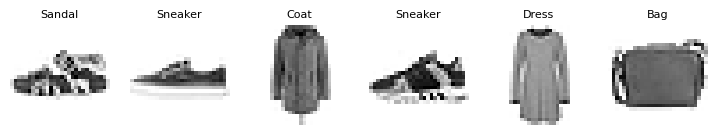

In [22]:
#testing Pytorch on fashion dataset
class_names=['T-shirt/top','Trouser','Pullover','Dress','Coat',
             'Sandal','Shirt','Sneaker','Bag','Ankle boot']
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
#let's look at a batch
images,labels=next(iter(train_loader))
plt.figure(figsize=(9,3))
for i in range(6):
  plt.subplot(1,6,i+1)
  plt.imshow(images[i].squeeze(),cmap="binary")
  plt.title(class_names[labels[i]],fontsize=8)
  plt.axis("off")
plt.show()


In [23]:
class FashionMLP(nn.Module):
  def __init__(self, ):
    super().__init__()
    self.flatten=nn.Flatten()
    self.net=nn.Sequential(
        nn.Linear(28*28,128),
        nn.ReLU(),
        nn.Linear(128,10)   # logits
    )
  def forward(self,x):
    return self.net(self.flatten(x))   #return raw logits

model=FashionMLP().to(device)
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)
print(model)

FashionMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [27]:
epochs=10
history={"train_loss":[],"train_acc":[],"val_loss":[],"val_acc":[]}
for epoch in range(epochs):
  tr_loss,tr_acc=train_one_epoch(model,train_loader,criterion,optimizer,device)
  val_loss,val_acc=evaluate(model,test_loader,criterion,device)

  for k,v in zip(history,[tr_loss,val_loss,tr_acc,val_acc]):
    history[k].append(v)
  print(f"Epoch {(epoch+1)}/{(epochs)} | train acc: {tr_acc} | test acc: {val_acc}")


Epoch 1/10 | train acc: 0.9279 | test acc: 0.8839
Epoch 2/10 | train acc: 0.9300833333333334 | test acc: 0.8803
Epoch 3/10 | train acc: 0.9306333333333333 | test acc: 0.8896
Epoch 4/10 | train acc: 0.9323333333333333 | test acc: 0.8845
Epoch 5/10 | train acc: 0.9337666666666666 | test acc: 0.8838
Epoch 6/10 | train acc: 0.9364166666666667 | test acc: 0.8919
Epoch 7/10 | train acc: 0.93755 | test acc: 0.886
Epoch 8/10 | train acc: 0.9386166666666667 | test acc: 0.887
Epoch 9/10 | train acc: 0.94165 | test acc: 0.8895
Epoch 10/10 | train acc: 0.9422833333333334 | test acc: 0.8865


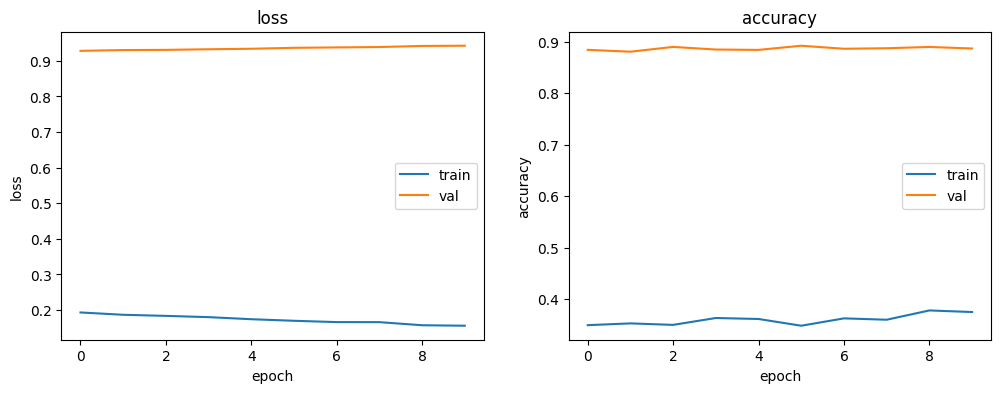

In [29]:
#plot the curves
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,4))
ax1.plot(history["train_loss"],label="train")
ax1.plot(history["val_loss"],label="val")
ax1.set_xlabel("epoch")
ax1.set_ylabel("loss")
ax1.set_title("loss")
ax2.plot(history["train_acc"],label="train")
ax2.plot(history["val_acc"],label="val")
ax2.set_xlabel("epoch")
ax2.set_ylabel("accuracy")
ax2.set_title("accuracy")
ax1.legend()
ax2.legend()
plt.show()

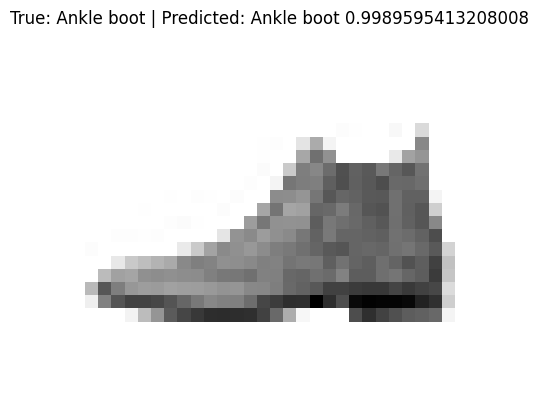

In [33]:
#inference on a single image
model.eval()
img,truth=test_ds[0]
with torch.no_grad():
  probs=torch.softmax(model(img.unsqueeze(0).to(device)),dim=1)
guess=probs.argmax(1).item()

plt.imshow(img.squeeze(),cmap="binary")
plt.title(f"True: {class_names[truth]} | Predicted: {class_names[guess]} {probs.max()}")
plt.axis("off")
plt.show()

In [35]:
#save and reload the model
torch.save(model.state_dict(),"fashion_pytorch.pth")

reloaded=FashionMLP().to(device)
reloaded.load_state_dict(torch.load("fashion_pytorch.pth",map_location=device))
reloaded.eval()

acc=evaluate(reloaded,test_loader,criterion,device)[1]
print("reloaded model test accuracy:",acc)

reloaded model test accuracy: 0.8865
